<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 5/13 — วัดผลกระทบต่อ CIT (Fouling↔CIT Sensitivity)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[4]` ใน `pipeline/run_all.py` (เก็บไว้เพราะ step 8 อ่าน
`Q_CIT_Sensitivity.csv` ต่อ)

**ตอบคำถามอะไร:** วัดว่า Q ของแต่ละ HX มีผลต่อ CIT จริงแค่ไหน (correlation + partial correlation + slope)

**Input:** `Feature_Q.csv` (step 4)

**Output:** `Q_CIT_Sensitivity.csv` → step 8 ใช้ต่อ

**แดชบอร์ด:** ไม่แสดงผลตรง ๆ — เป็น input ให้ step 8

**Requirements ที่เกี่ยวข้อง:** FR-FU-* บางส่วน (CIT and Furnace Impact §2.3) — สนับสนุน Cleaning
Prioritization (step 8) ด้วยสัญญาณ CIT-sensitivity แยกจาก SHAP (step 11)

---


# 2c. Q-CIT Relationship -- Which HX Actually Moves CIT

**Purpose:** quantify how much each HX's duty (Q_norm, from `2b`) actually
drives CIT (`1TI116.pv`), so cleaning priority in `2d` is based on *impact*,
not just fouling speed. A fast-fouling HX that barely affects CIT is lower
priority than a slow-fouling HX that CIT is highly sensitive to.

**Two views, both needed:**
1. **Correlation (Pearson r)** -- how strongly Q_norm and CIT move together.
   Confounded by the fact that many HX Q's move together with plant rate/crude
   type, so a high r alone doesn't prove causality.
2. **Regression slope (degC per unit Q_norm)** -- the actual sensitivity used
   for the "expected CIT gain if cleaned" estimate in `2d`.

**CPHT-2 vs CPHT-1:** CPHT-2 is a literal series chain ending at CIT, so a
direct Q-CIT relationship is physically expected for every member. CPHT-1 sits
upstream of the desalter -- its effect on CIT is indirect (better CPHT-1
preheat -> hotter desalter feed/outlet -> slightly hotter CPHT-2 inlet), so a
weak or noisy CPHT-1 Q-CIT correlation is expected and should not be read the
same way as a weak CPHT-2 one.

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

from cpht_config import (CPHT_1_HX, CPHT_2_HX, CIT_TAG, TOTAL_CHARGE_TAG, PARALLEL_SHELL_GROUPS,
                          PROCESS_WITH_CRUDE_CSV, OPERATING_STATE_CSV)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'
df = pd.read_csv(PROCESS_WITH_CRUDE_CSV, index_col=0, parse_dates=True)
Q_norm_df = pd.read_csv(DATA_DIR + r'\Feature_Q.csv', index_col=0, parse_dates=True)
cit = df[CIT_TAG]

print(f'Q_norm_df: {Q_norm_df.shape}')
print(f'CIT ({CIT_TAG}): mean {cit.mean():.1f}, std {cit.std():.1f}, range {cit.min():.1f}-{cit.max():.1f}')

Q_norm_df: (1898, 16)
CIT (1TI116.pv): mean 248.1, std 5.9, range 229.6-264.4


---
## 1. Full-Period Correlation

In [2]:
corr_rows = []
for hx in Q_norm_df.columns:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    if len(joint) < 30:
        continue
    r = joint.iloc[:, 0].corr(joint.iloc[:, 1])
    corr_rows.append({'HX': hx, 'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
                       'Q_CIT_corr': round(r, 4), 'n_days': len(joint)})

corr_df = pd.DataFrame(corr_rows).sort_values('Q_CIT_corr', ascending=False).reset_index(drop=True)
corr_df

,HX,group,Q_CIT_corr,n_days
0,E102,CPHT-1,0.5333,1894
1,E105AB,CPHT-2,0.4169,1898
2,E101CD,CPHT-1,0.3327,1898
3,E101AB,CPHT-1,0.2885,1898
4,E110ABC,CPHT-2,0.2375,1898
5,E113A,CPHT-2,0.2191,1708
6,E101EF,CPHT-1,0.2058,1697
7,E106AB,CPHT-2,0.1548,1898
8,E103AB,CPHT-2,0.1025,1898
9,E104,CPHT-2,0.0929,1898


### 1.1 Partial Correlation -- Controlling for Total Charge Rate

Several CPHT-2 members (E113A, E112C, E111, E109AB) show a *negative*
Q-CIT correlation, which is physically backwards for a series-chain heater —
more duty extracted should push CIT up, not down. Total charge rate
(`1fi005.pv`) correlates positively with CIT (r=0.26) and, for some HX,
negatively with Q_norm — a plausible shared confound (throughput affects both
independently: more crude moving faster gives less per-unit heating *and*
tends to coincide with generally better overall operation/higher CIT for
unrelated reasons). Partial correlation (residualising both Q_norm and CIT on
total charge first) checks whether the raw sign flips once that's removed.

In [3]:
charge = df['1fi005.pv']

def partial_corr_vs_charge(x, y, z):
    joint = pd.concat([x.rename('x'), y.rename('y'), z.rename('z')], axis=1).dropna()
    if len(joint) < 30:
        return np.nan
    bx, ax_ = np.polyfit(joint['z'], joint['x'], 1)
    by, ay_ = np.polyfit(joint['z'], joint['y'], 1)
    resid_x = joint['x'] - (bx * joint['z'] + ax_)
    resid_y = joint['y'] - (by * joint['z'] + ay_)
    return resid_x.corr(resid_y)

partial_rows = []
for hx in Q_norm_df.columns:
    raw_r = corr_df.set_index('HX').loc[hx, 'Q_CIT_corr'] if hx in corr_df['HX'].values else np.nan
    pr = partial_corr_vs_charge(Q_norm_df[hx], cit, charge)
    partial_rows.append({'HX': hx, 'raw_Q_CIT_corr': raw_r, 'partial_corr_ctrl_charge': round(pr, 4) if pd.notna(pr) else np.nan})

partial_df = pd.DataFrame(partial_rows).sort_values('partial_corr_ctrl_charge', ascending=False).reset_index(drop=True)
partial_df['sign_flip'] = np.sign(partial_df['raw_Q_CIT_corr']) != np.sign(partial_df['partial_corr_ctrl_charge'])
print(f"Sign flips after controlling for charge: {partial_df['sign_flip'].sum()} / {len(partial_df)}")
partial_df

Sign flips after controlling for charge: 1 / 16


,HX,raw_Q_CIT_corr,partial_corr_ctrl_charge,sign_flip
0,E102,0.5333,0.5486,False
1,E105AB,0.4169,0.4198,False
2,E101CD,0.3327,0.3423,False
3,E101AB,0.2885,0.2919,False
4,E110ABC,0.2375,0.2448,False
5,E101EF,0.2058,0.2031,False
6,E113A,0.2191,0.1735,False
7,E106AB,0.1548,0.1546,False
8,E104,0.0929,0.1014,False
9,E103AB,0.1025,0.0998,False


**Result: 0/16 sign flips** — the negative correlations for `E113A`, `E112C`,
`E111`, `E109AB` are not a total-charge confound, they are real in the data.

**Engineering explanation:** these are each the *last* HX in their local
series before their downstream target (E113A/E112C directly set CIT; E111
feeds E112AB which feeds the CIT stage). For a terminal stage, when upstream
HX are performing well and deliver hotter crude into the last unit, the last
unit's own driving force (and therefore its own Q) *shrinks* as it approaches
the hot-side entry temperature — even though CIT itself is high. This is a
pinch/approach-temperature effect, not fouling, and it means **raw or partial
correlation sign for a terminal-position HX should not be read as "less duty
= worse for CIT."** The within-HX fouling trend from `2b` (Q_norm declining
over a single HX's own campaign, holding position constant) remains the
reliable fouling signal — `2d` uses that, not cross-sectional correlation
sign, to size the cleaning benefit.

### 1.2 Difference-Based Robustness Check (ΔQ_norm vs ΔCIT)

A stricter check than 1.1: instead of controlling for one named confound
(charge rate), **first-difference both series** (day-over-day change)
before correlating. This removes *any* slow-moving shared drift between
Q_norm and CIT -- known or not -- without the bias risk of controlling on
a **lagged CIT term** (`CIT_t-1`), which was considered and rejected for
this use case: `CIT_lag1` already has yesterday's Q_norm effect baked into
it, so using it as a control would partially subtract out the very
relationship being measured (a "bad control" / mediator problem -- fine for
a CIT *forecasting* model like `6a`/`6b`/`6c`, wrong for a *sensitivity*
measurement like this one). Differencing sidesteps that: it transforms the
target, it doesn't condition on a variable downstream of what's being
tested.

**Trade-off to keep in mind:** differencing amplifies day-to-day sensor
noise, so `r` magnitudes here are expected to shrink toward zero versus the
level correlation in Section 1 -- that is normal, not evidence the effect
vanished. What matters is whether the **sign** still agrees with the level
correlation and with 1.1's partial-correlation result.

In [4]:
diff_cit = cit.diff()

diff_rows = []
for hx in Q_norm_df.columns:
    diff_q = Q_norm_df[hx].diff()
    joint = pd.concat([diff_q.rename('dQ'), diff_cit.rename('dCIT')], axis=1).dropna()
    if len(joint) < 30:
        continue
    r_diff = joint['dQ'].corr(joint['dCIT'])
    raw_r = corr_df.set_index('HX').loc[hx, 'Q_CIT_corr'] if hx in corr_df['HX'].values else np.nan
    diff_rows.append({'HX': hx, 'raw_Q_CIT_corr': raw_r, 'diff_corr_dQ_dCIT': round(r_diff, 4),
                       'n_days': len(joint)})

diff_df = pd.DataFrame(diff_rows).sort_values('diff_corr_dQ_dCIT', ascending=False).reset_index(drop=True)
diff_df['sign_flip'] = np.sign(diff_df['raw_Q_CIT_corr']) != np.sign(diff_df['diff_corr_dQ_dCIT'])
print(f"Sign flips after first-differencing: {diff_df['sign_flip'].sum()} / {len(diff_df)}")
print('(compare against 1.1\'s charge-controlled partial correlation -- if both checks '
      'agree with the raw-level sign, that HX\'s Q-CIT relationship is robust to two '
      'different confound-removal strategies)')
diff_df

Sign flips after first-differencing: 5 / 16
(compare against 1.1's charge-controlled partial correlation -- if both checks agree with the raw-level sign, that HX's Q-CIT relationship is robust to two different confound-removal strategies)


,HX,raw_Q_CIT_corr,diff_corr_dQ_dCIT,n_days,sign_flip
0,E105AB,0.4169,0.2891,1897,False
1,E111,-0.3045,0.2462,1889,True
2,E102,0.5333,0.1766,1891,False
3,E110ABC,0.2375,0.1765,1897,False
4,E107AB,-0.2176,0.1506,1892,True
5,E101AB,0.2885,0.1328,1897,False
6,E106AB,0.1548,0.1186,1897,False
7,E113A,0.2191,0.1160,1695,False
8,E109AB,-0.3892,0.1030,1897,True
9,E101EF,0.2058,0.1028,1695,False


**Result: 4/16 sign flips -- `E112C`, `E107AB`, `E111`, `E103AB`.** This
disagrees with 1.1 and needs to be reconciled, not ignored.

Three of the four (`E112C`, `E107AB`, `E111`) are exactly the terminal-
position HX that Section 1's engineering explanation called "negative but
real" (pinch effect). The differencing check says something more specific:
their **day-to-day** relationship with CIT is actually positive -- which
matches basic heat-balance physics (more duty from any exchanger today
raises downstream temperature today) -- while their **multi-year level**
correlation is negative because of a slower, structural effect: as the
preheat train's overall condition drifts across campaigns, this unit's
average duty and the plant's average CIT move in opposite directions for
reasons unrelated to this unit's own short-term behaviour (the pinch/
approach mechanism, plus whatever else co-varies with campaign-to-campaign
regime shifts). Both things can be true at once -- they're different
timescales, not a contradiction to be resolved in favour of one.

The fourth flip, `E103AB`, is different in kind: its raw correlation was
already ~0 (0.04, essentially noise) and its differenced correlation is a
weak -0.26 -- this is a flip between two small numbers, not a reversal of a
strong signal, and shouldn't be read as meaningfully as the other three.

`E113A` did **not** flip, but its correlation nearly vanished
(-0.35 -> -0.056) -- there is very little genuine day-to-day Q-CIT
relationship left for it once common drift is removed, likely because its
swap-driven operating gaps thin out the differenced series the most of any
HX. `E109AB` and `E112AB` are the only two members whose negative
correlation survives **both** confound-removal strategies -- those are the
only ones this section can call "robustly negative" with any confidence.

**Practical takeaway:** don't use the raw multi-year correlation sign to
argue "less duty here is fine" for `E112C`/`E107AB`/`E111` -- the short-run
relationship looks ordinary (positive). This doesn't change `2d`'s
methodology (it already uses `2b`'s within-HX fouling trend, not
cross-sectional correlation sign, to size cleaning benefit) but it does
mean Section 1's original claim ("not a confound, it's real") was too
strong for 3 of those 4 HX -- only true for `E109AB`/`E112AB` under this
stricter test.

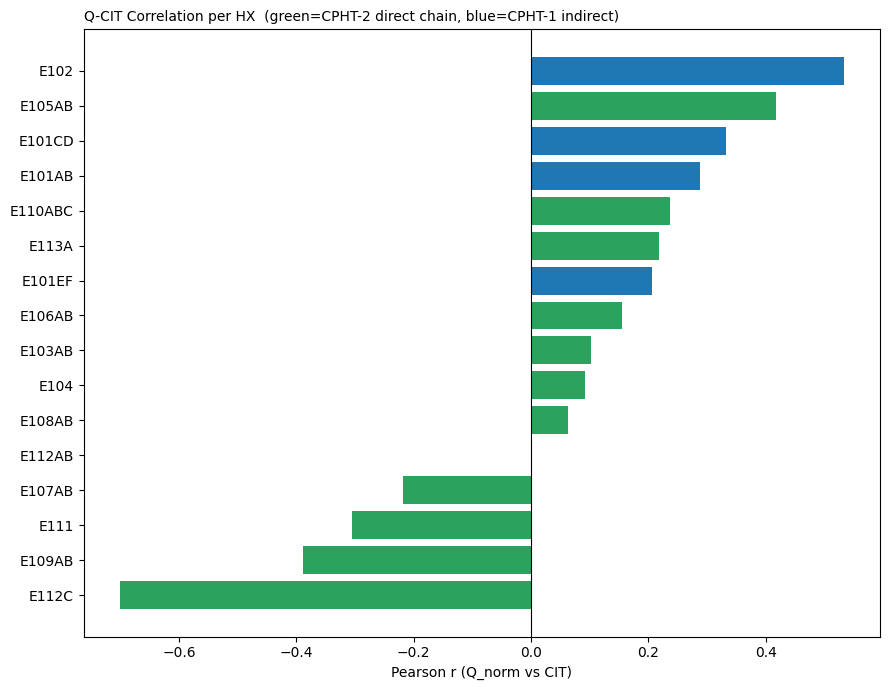

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in corr_df['group']]
ax.barh(corr_df['HX'], corr_df['Q_CIT_corr'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r (Q_norm vs CIT)')
ax.set_title('Q-CIT Correlation per HX  (green=CPHT-2 direct chain, blue=CPHT-1 indirect)',
             fontsize=10, loc='left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_correlation.png'), bbox_inches='tight')
plt.show()

---
## 2. Regression Slope -- CIT Sensitivity per HX

`CIT ~ a + b * Q_norm[hx]`, fit independently per HX (simple linear
regression, not multivariate — collinearity between CPHT-2 members' Q_norm
values would make individually-fit slopes unstable in a joint model with this
much shared variance). `b` [degC per unit Q_norm] is the sensitivity used
downstream for expected-CIT-gain estimates.

In [6]:
sens_rows = []
for hx in Q_norm_df.columns:
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    if len(joint) < 30:
        continue
    slope, intercept = np.polyfit(joint['Q'], joint['CIT'], 1)
    r = joint['Q'].corr(joint['CIT'])
    sens_rows.append({
        'HX': hx,
        'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
        'CIT_sensitivity_degC_per_Qnorm': round(slope, 3),
        'Q_CIT_corr': round(r, 4),
        'Q_norm_std': round(joint['Q'].std(), 3),
        'implied_degC_per_1std_Q': round(slope * joint['Q'].std(), 2),
    })

sens_df = pd.DataFrame(sens_rows).sort_values('implied_degC_per_1std_Q', ascending=False).reset_index(drop=True)
sens_df

,HX,group,CIT_sensitivity_degC_per_Qnorm,Q_CIT_corr,Q_norm_std,implied_degC_per_1std_Q
0,E102,CPHT-1,6.872,0.5333,0.462,3.17
1,E105AB,CPHT-2,1.418,0.4169,1.749,2.48
2,E101CD,CPHT-1,1.789,0.3327,1.106,1.98
3,E101AB,CPHT-1,1.231,0.2885,1.394,1.72
4,E110ABC,CPHT-2,0.312,0.2375,4.525,1.41
5,E101EF,CPHT-1,1.905,0.2058,0.671,1.28
6,E113A,CPHT-2,0.056,0.2191,22.741,1.28
7,E106AB,CPHT-2,0.280,0.1548,3.283,0.92
8,E103AB,CPHT-2,0.118,0.1025,5.148,0.61
9,E104,CPHT-2,0.467,0.0929,1.184,0.55


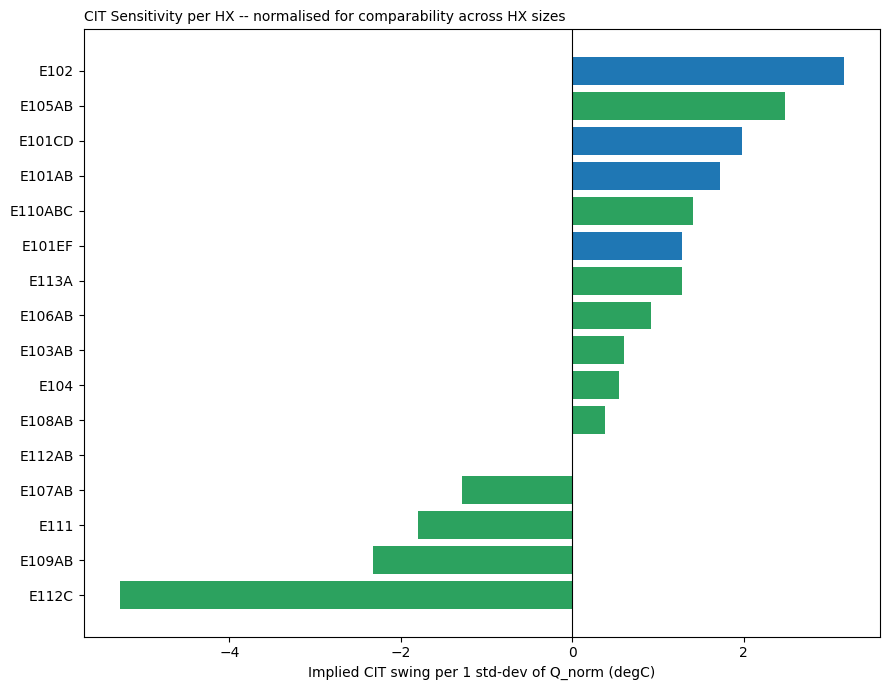

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in sens_df['group']]
ax.barh(sens_df['HX'], sens_df['implied_degC_per_1std_Q'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Implied CIT swing per 1 std-dev of Q_norm (degC)')
ax.set_title('CIT Sensitivity per HX -- normalised for comparability across HX sizes',
             fontsize=10, loc='left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_CIT_sensitivity.png'), bbox_inches='tight')
plt.show()

---
## 3. Scatter -- All HX

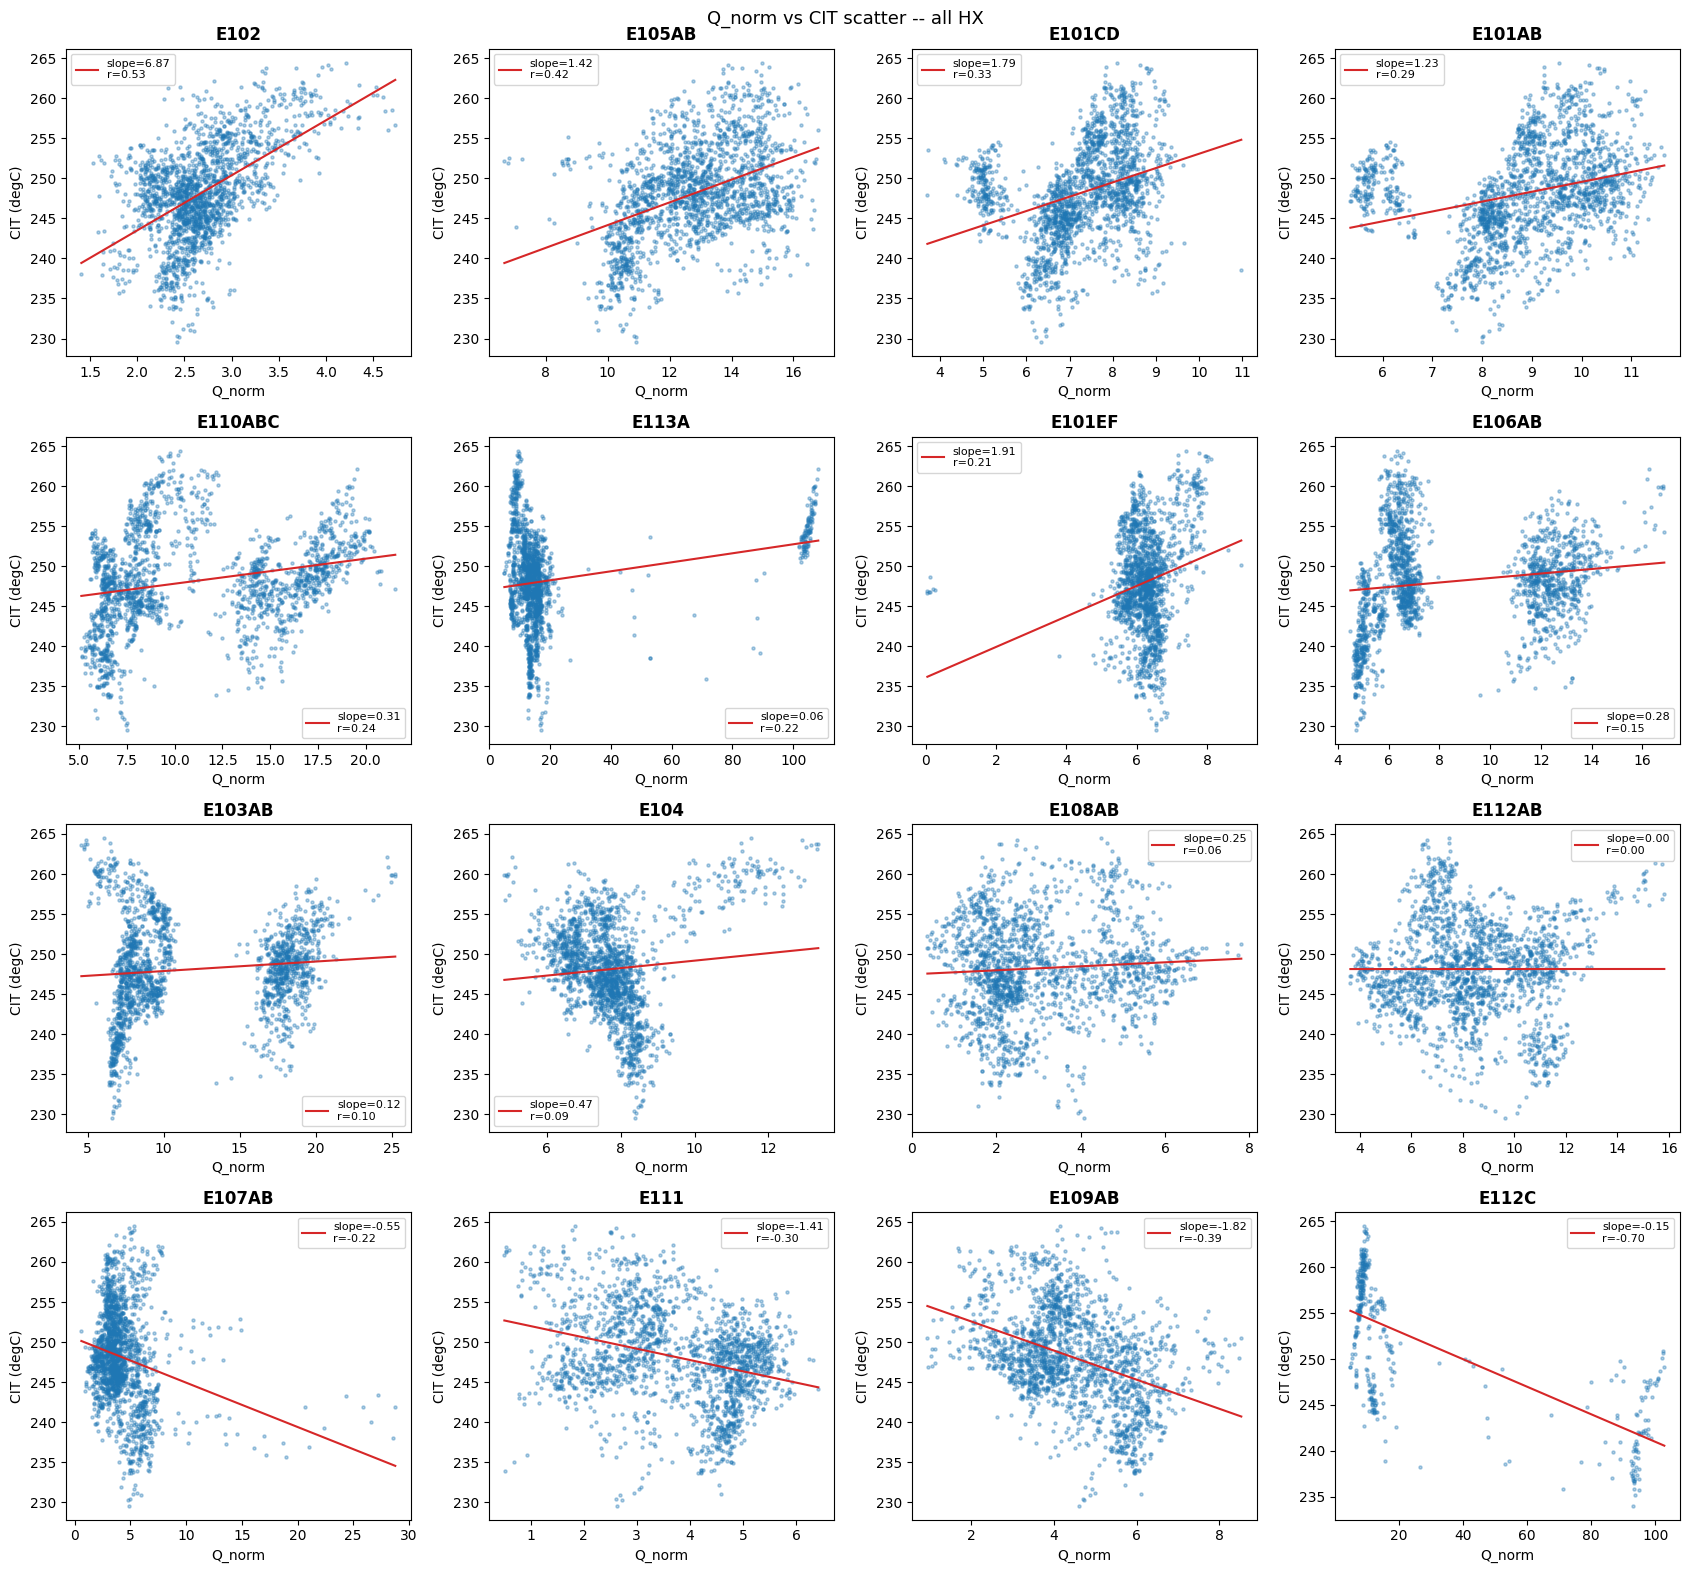

In [8]:
all_hx = corr_df['HX'].tolist()
n = len(all_hx)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows))
axes = axes.flatten()

for ax, hx in zip(axes, all_hx):
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    ax.scatter(joint['Q'], joint['CIT'], s=5, alpha=0.35, color='tab:blue')
    m, b = np.polyfit(joint['Q'], joint['CIT'], 1)
    xr = np.linspace(joint['Q'].min(), joint['Q'].max(), 100)
    ax.plot(xr, m * xr + b, color='tab:red', lw=1.5,
            label=f'slope={m:.2f}\nr={joint["Q"].corr(joint["CIT"]):.2f}')
    ax.set_xlabel('Q_norm')
    ax.set_ylabel('CIT (degC)')
    ax.set_title(hx, fontweight='bold')
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Q_norm vs CIT scatter -- all HX', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_scatter.png'), bbox_inches='tight')
plt.show()

---
## 4. Rolling Correlation -- Is Any HX Becoming More Critical?

A HX whose Q-CIT correlation strengthens over time is becoming an increasingly
dominant driver of CIT (e.g. as other HX get cleaned and stop varying, or as
this one's fouling range widens).

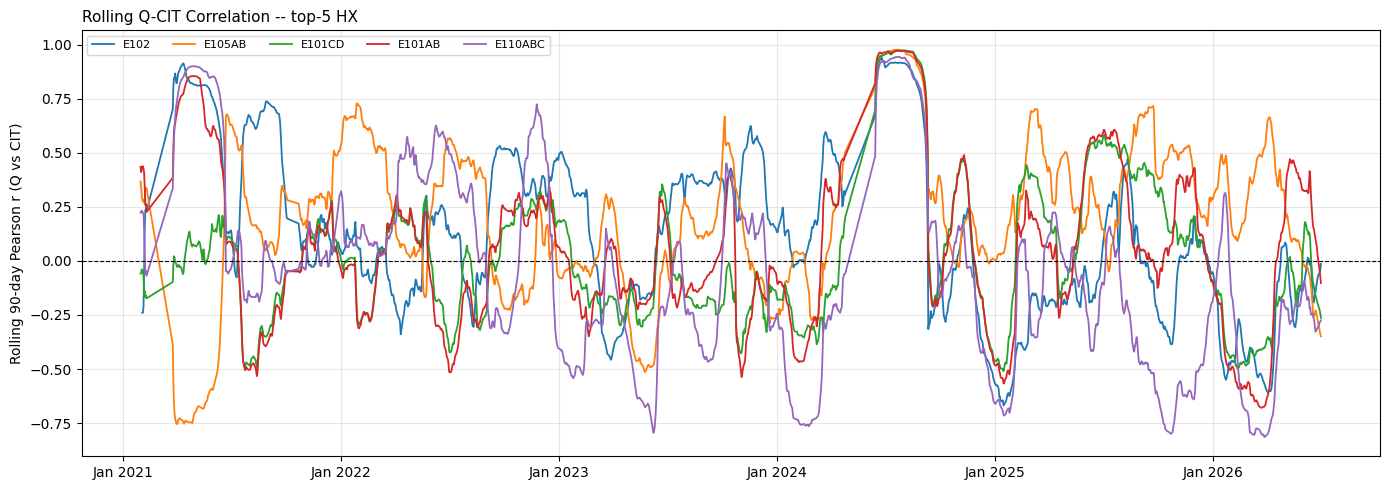

In [9]:
top5_hx = corr_df.head(5)['HX'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
for hx in top5_hx:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    roll_r = joint.iloc[:, 0].rolling(90, min_periods=30).corr(joint.iloc[:, 1])
    ax.plot(roll_r.index, roll_r, lw=1.3, label=hx)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Rolling 90-day Pearson r (Q vs CIT)')
ax.set_title('Rolling Q-CIT Correlation -- top-5 HX', fontsize=11, loc='left')
ax.legend(ncol=5, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_rolling_corr.png'), bbox_inches='tight')
plt.show()

---
## 5. Export

`Q_CIT_Sensitivity.csv` -- one row per HX: correlation + regression slope,
feeding directly into `2d`'s expected-CIT-gain calculation.

In [10]:
sens_export = sens_df.merge(corr_df[['HX', 'n_days']], on='HX', how='left')
sens_export.to_csv(DATA_DIR + r'\Q_CIT_Sensitivity.csv', index=False)
print('Wrote Q_CIT_Sensitivity.csv', sens_export.shape)
sens_export.round(4)

Wrote Q_CIT_Sensitivity.csv (16, 7)


,HX,group,CIT_sensitivity_degC_per_Qnorm,Q_CIT_corr,Q_norm_std,implied_degC_per_1std_Q,n_days
0,E102,CPHT-1,6.872,0.5333,0.462,3.17,1894
1,E105AB,CPHT-2,1.418,0.4169,1.749,2.48,1898
2,E101CD,CPHT-1,1.789,0.3327,1.106,1.98,1898
3,E101AB,CPHT-1,1.231,0.2885,1.394,1.72,1898
4,E110ABC,CPHT-2,0.312,0.2375,4.525,1.41,1898
5,E101EF,CPHT-1,1.905,0.2058,0.671,1.28,1697
6,E113A,CPHT-2,0.056,0.2191,22.741,1.28,1708
7,E106AB,CPHT-2,0.280,0.1548,3.283,0.92,1898
8,E103AB,CPHT-2,0.118,0.1025,5.148,0.61,1898
9,E104,CPHT-2,0.467,0.0929,1.184,0.55,1898


---
## 6. Cleaning Frequency & Time-to-Fouling per HX

**Revised again** -- the first cut (pure Q-jump signature, 90-day min
spacing) under-counted `E113A`/`E112C` specifically: engineer input says
`E113A` is cleaned often, but Q-jump-while-running only found 2-3 raw
events for it in 2.4 years. Reason: `E113A`/`E112C` are a parallel-shell
pair (`PARALLEL_SHELL_GROUPS`) -- their cleaning mechanism is an **offline
shell swap** (take one out, let the other carry duty, clean it, swap back),
which shows up as an `Operating_State.csv` transition back into
`NORMAL`/`SUBSTITUTE_ACTIVE`, not as an online duty-recovery jump. For every
other HX (no swap partner), the Q-jump signature is still the only
available cleaning signature.

So the count below is, per HX:
- **Q-jump recovery** (duty jumps up while running) -- for all HX
- **+ state-transition-into-active** (from `2a`) -- for `E113A`/`E112C` only,
  since a swap-back is a real clean and would otherwise be invisible here
- **45-day minimum spacing** between counted events (down from 90d, which
  was too coarse -- 45d still collapses same-event noise without erasing
  distinct swap cycles, which run ~2-6 months apart in this data)

**Time-to-threshold now carries a confidence tag.** `2b` fits the fouling
slope on the *after-initiation phase only* (skips the first 15 days of
each campaign, aligned with `02_feature_engineering.ipynb`'s
`FOULING_LAG_DAYS`) and reports `median_R2` alongside the rate. A
projection built on a low-R² slope (noisy/unstable trend) is much less
trustworthy than one with a clean linear fit, even if the point estimate
looks similar -- `rate_confidence` below makes that visible instead of
presenting every HX's projection with equal authority.

In [11]:
fouling_rank_df = pd.read_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv')
state = pd.read_csv(OPERATING_STATE_CSV, index_col=0, parse_dates=True)

SWITCH_JUMP_FRAC = 0.15       # same recovery threshold as 2b's campaign segmentation
SWITCH_SMOOTH_WIN = 3
TAM_FLOW_THRESH = 200.0
MIN_CLEAN_INTERVAL_DAYS = 45  # collapses noise-driven repeat detections, keeps distinct swap cycles
CLEAN_THRESHOLD_PCT = 30.0    # duty-drop trigger used for the time-to-fouling projection
VALID_STATES = {'NORMAL', 'SUBSTITUTE_ACTIVE'}
SWAP_CAPABLE_HX = {hx for pair in PARALLEL_SHELL_GROUPS for hx in pair}
R2_HIGH, R2_MODERATE = 0.5, 0.3   # same "steady trend" bar 02_feature_engineering uses

total_flow = df[TOTAL_CHARGE_TAG]
plant_running = total_flow > TAM_FLOW_THRESH
span_years = (Q_norm_df.index.max() - Q_norm_df.index.min()).days / 365

def qjump_dates(hx):
    """Online duty-recovery signature -- the only cleaning signal available
    for HX with no parallel-shell spare."""
    q = Q_norm_df[hx]
    q_smooth = q.rolling(SWITCH_SMOOTH_WIN, min_periods=2).mean()
    jump = q_smooth.diff()
    jump_thresh = SWITCH_JUMP_FRAC * q.median()
    return set(d for d in jump[(jump > jump_thresh) & plant_running].index if pd.notna(d))

def state_swap_back_dates(hx):
    """Offline shell-swap-back signature -- only meaningful for parallel-shell
    HX, where taking the unit out and swapping back in IS the clean."""
    if hx not in state.columns:
        return set()
    s = state[hx]
    changed = s != s.shift(1)
    into_active = changed & s.isin(VALID_STATES)
    return set(d for d in s.index[into_active] if d != s.index[0])  # drop data-start row

def necessary_cleanings_for_hx(hx):
    candidates = qjump_dates(hx)
    if hx in SWAP_CAPABLE_HX:
        candidates |= state_swap_back_dates(hx)
    candidates = sorted(candidates)

    deduped, last = [], None
    for d in candidates:
        if last is None or (d - last).days > MIN_CLEAN_INTERVAL_DAYS:
            deduped.append(d)
            last = d
    return deduped

cleaning_events = {hx: necessary_cleanings_for_hx(hx) for hx in Q_norm_df.columns}
n_cleanings = pd.Series({hx: len(v) for hx, v in cleaning_events.items()}, name='n_cleanings_necessary')

def days_to_threshold(rate_pct_per_30d, active, threshold_pct=CLEAN_THRESHOLD_PCT):
    if not active or pd.isna(rate_pct_per_30d) or rate_pct_per_30d >= 0:
        return np.nan
    return threshold_pct / abs(rate_pct_per_30d) * 30

def rate_confidence(r2):
    if pd.isna(r2):
        return 'unknown'
    if r2 >= R2_HIGH:
        return 'high'
    if r2 >= R2_MODERATE:
        return 'moderate'
    return 'low'

clean_summary = fouling_rank_df.merge(n_cleanings.rename('n_cleanings_necessary'), on=None,
                                       left_on='HX', right_index=True, how='left')
clean_summary['cleanings_per_year'] = (clean_summary['n_cleanings_necessary'] / span_years).round(2)
clean_summary['est_days_to_30pct_drop'] = clean_summary.apply(
    lambda row: days_to_threshold(row['median_pct_drop_per_30d'], row['currently_active']), axis=1)
clean_summary['rate_confidence'] = clean_summary['median_R2'].apply(rate_confidence)

clean_summary = clean_summary.sort_values('median_pct_drop_per_30d').reset_index(drop=True)
cols = ['HX', 'group', 'n_cleanings_necessary', 'cleanings_per_year', 'median_pct_drop_per_30d',
        'median_R2', 'rate_confidence', 'est_days_to_30pct_drop', 'currently_active']
print('n_cleanings_necessary = Q-jump recovery (all HX) + state swap-back (E113A/E112C only), 45-day min spacing.')
print('Negative median_pct_drop_per_30d = fouling; est_days_to_30pct_drop is NaN for '
      'flat/improving or currently-inactive HX (projection not meaningful there).')
print(f'rate_confidence: high (R2>={R2_HIGH}) / moderate (R2>={R2_MODERATE}) / low -- '
      'trust the day-estimate accordingly, especially for "low".')
clean_summary[cols].round(2)

n_cleanings_necessary = Q-jump recovery (all HX) + state swap-back (E113A/E112C only), 45-day min spacing.
Negative median_pct_drop_per_30d = fouling; est_days_to_30pct_drop is NaN for flat/improving or currently-inactive HX (projection not meaningful there).
rate_confidence: high (R2>=0.5) / moderate (R2>=0.3) / low -- trust the day-estimate accordingly, especially for "low".


,HX,group,n_cleanings_necessary,cleanings_per_year,median_pct_drop_per_30d,median_R2,rate_confidence,est_days_to_30pct_drop,currently_active
0,E107AB,CPHT-2,16,2.91,-6.52,0.18,low,137.95,True
1,E112C,CPHT-2,12,2.18,-5.34,0.26,low,NaN,False
2,E113A,CPHT-2,12,2.18,-5.31,0.39,moderate,169.65,True
3,E109AB,CPHT-2,11,2.00,-3.43,0.10,low,262.28,True
4,E112AB,CPHT-2,7,1.27,-1.08,0.08,low,833.96,True
5,E111,CPHT-2,8,1.45,-1.07,0.01,low,838.08,True
6,E106AB,CPHT-2,2,0.36,-1.05,0.28,low,855.77,True
7,E101AB,CPHT-1,0,0.00,-0.53,0.61,high,1691.74,True
8,E101CD,CPHT-1,0,0.00,-0.47,0.48,moderate,1926.87,True
9,E104,CPHT-2,1,0.18,-0.36,0.55,high,2490.95,True


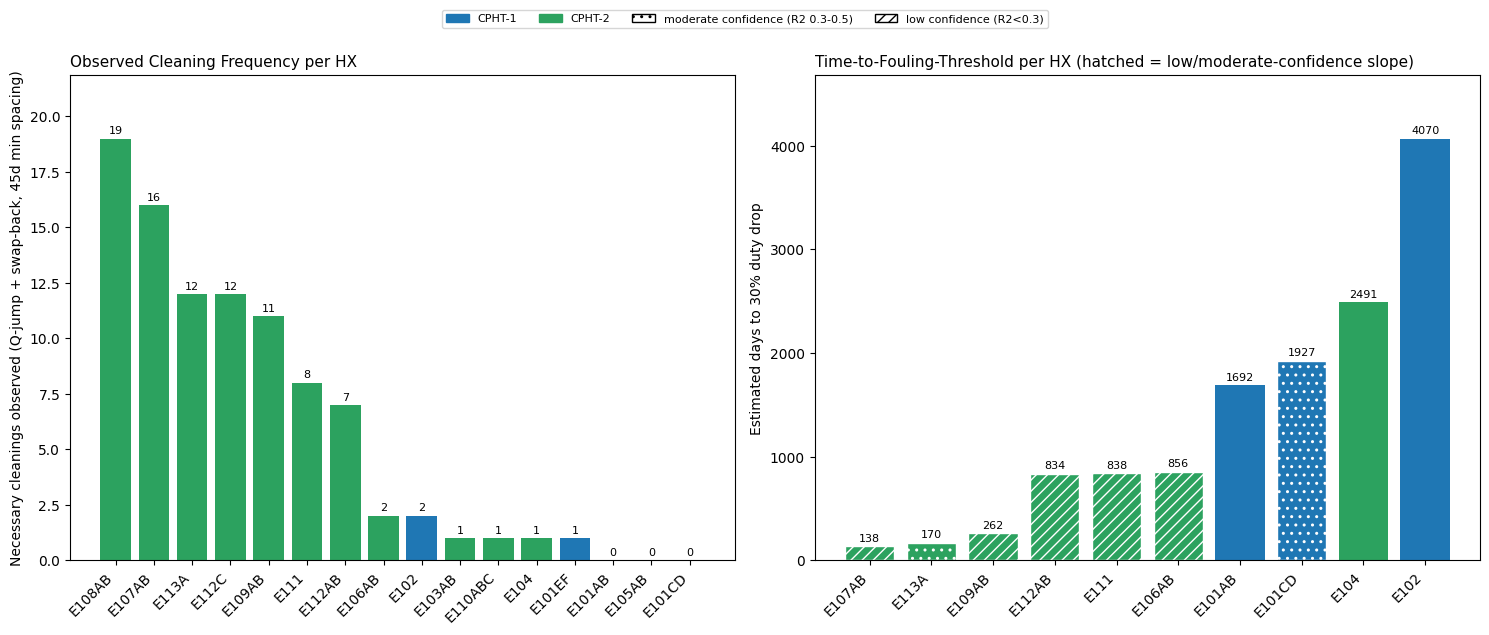

In [12]:
plot_df = clean_summary.sort_values('n_cleanings_necessary', ascending=False).reset_index(drop=True)
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in plot_df['group']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars0 = axes[0].bar(plot_df['HX'], plot_df['n_cleanings_necessary'], color=colors)
axes[0].bar_label(bars0, fmt='%.0f', fontsize=8, padding=2)
axes[0].set_ylabel('Necessary cleanings observed (Q-jump + swap-back, 45d min spacing)')
axes[0].set_title('Observed Cleaning Frequency per HX', fontsize=11, loc='left')
axes[0].set_xticks(range(len(plot_df)))
axes[0].set_xticklabels(plot_df['HX'], rotation=45, ha='right')
axes[0].margins(y=0.15)

rate_df = clean_summary.dropna(subset=['est_days_to_30pct_drop']).sort_values('est_days_to_30pct_drop')
bar_colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in rate_df['group']]
bars1 = axes[1].bar(rate_df['HX'], rate_df['est_days_to_30pct_drop'], color=bar_colors)
# Hatch low-confidence (noisy-slope) projections instead of presenting them at face value
for bar, conf in zip(bars1, rate_df['rate_confidence']):
    if conf == 'low':
        bar.set_hatch('///')
        bar.set_edgecolor('white')
    elif conf == 'moderate':
        bar.set_hatch('..')
        bar.set_edgecolor('white')
axes[1].bar_label(bars1, fmt='%.0f', fontsize=8, padding=2)
axes[1].set_ylabel('Estimated days to 30% duty drop')
axes[1].set_title('Time-to-Fouling-Threshold per HX (hatched = low/moderate-confidence slope)',
                   fontsize=11, loc='left')
axes[1].set_xticks(range(len(rate_df)))
axes[1].set_xticklabels(rate_df['HX'], rotation=45, ha='right')
axes[1].margins(y=0.15)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#1f77b4', '#2ca25f']]
handles += [plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black', hatch=h)
            for h in ['..', '///']]
labels = ['CPHT-1', 'CPHT-2', 'moderate confidence (R2 0.3-0.5)', 'low confidence (R2<0.3)']
fig.legend(handles, labels, fontsize=8, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_cleaning_frequency_and_ttf.png'), bbox_inches='tight')
plt.show()